In [1]:
import torch
import random
import numpy as np

# --------------------------------------------------
# Reproducibility Seed
# --------------------------------------------------

seed = 42

random.seed(seed)
np.random.seed(seed)

torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

print("Random seed set for reproducibility.")

Random seed set for reproducibility.


# *Loading Data*

In [2]:
train = "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/train"
test = "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/test"
validation = "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/validation"

In [3]:
import os

def load_images_from_dirs(dir_list):
    all_images = []

    for directory in dir_list:
        for img in os.listdir(directory):
            img_path = os.path.join(directory, img)

            if os.path.isfile(img_path):
                all_images.append(img_path)

    return all_images

In [4]:
test_fake_dirs = [
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/test/Deepfakes",
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/test/Face2Face",
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/test/FaceShifter",
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/test/FaceSwap",
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/test/NeuralTextures"
]

test_real_dirs = [
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/test/real"
]

test_fake = load_images_from_dirs(test_fake_dirs)
test_real = load_images_from_dirs(test_real_dirs)

print(len(test_fake))
print(len(test_real))

2250
2250


In [5]:
train_fake_dirs = [
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/train/Deepfakes",
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/train/Face2Face",
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/train/FaceShifter",
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/train/FaceSwap",
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/train/NeuralTextures"
]

train_real_dirs = [
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/train/real"
]

train_fake = load_images_from_dirs(train_fake_dirs)
train_real = load_images_from_dirs(train_real_dirs)

print(len(train_fake))
print(len(train_real))

10500
10500


In [6]:
validation_fake_dirs = [
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/validation/Deepfakes",
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/validation/Face2Face",
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/validation/FaceShifter",
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/validation/FaceSwap",
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/validation/NeuralTextures"
]

validation_real_dirs = [
    "/kaggle/input/datasets/vaishnavitripathi217/dataset-face-forensic/final_deepfake_project_dataset/validation/real"
]

validation_fake = load_images_from_dirs(validation_fake_dirs)
validation_real = load_images_from_dirs(validation_real_dirs)

print(len(validation_fake))
print(len(validation_real))

2250
2250


# Data loaders 


In [7]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import time
import copy

class DeepfakeDataset(Dataset):
    def __init__(self, fake_paths, real_paths, transform=None):
        
        self.image_paths = fake_paths + real_paths
        self.labels = [1] * len(fake_paths) + [0] * len(real_paths)
        
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        
        img_path = self.image_paths[idx]
        label = self.labels[idx]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [8]:
IMG_SIZE = 299

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [9]:
train_dataset = DeepfakeDataset(
    train_fake,
    train_real,
    transform=train_transform
)

val_dataset = DeepfakeDataset(
    validation_fake,
    validation_real,
    transform=val_test_transform
)

test_dataset = DeepfakeDataset(
    test_fake,
    test_real,
    transform=val_test_transform
)

In [10]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

In [11]:
print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

21000
4500
4500
torch.Size([32, 3, 299, 299])
torch.Size([32])


# *Train Model Function*

In [12]:
# ============================================================
# TRAINING FUNCTION
# ============================================================

def train_model(
    model,
    criterion,
    optimizer,
    train_loader,
    val_loader,
    num_epochs=25,
    patience=5,
    save_path="best_model.pth"
):

    since = time.time()

    # --------------------------------------------------------
    # AUTOMATIC DEVICE DETECTION
    # --------------------------------------------------------

    device = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )

    model = model.to(device)

    # --------------------------------------------------------
    # BEST MODEL TRACKING
    # --------------------------------------------------------

    best_model_wts = copy.deepcopy(model.state_dict())

    best_acc = 0.0

    epochs_no_improve = 0

    early_stop = False

    # --------------------------------------------------------
    # HISTORY TRACKING
    # --------------------------------------------------------

    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }

    # ========================================================
    # EPOCH LOOP
    # ========================================================

    for epoch in range(num_epochs):

        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        # ====================================================
        # TRAIN + VALIDATION PHASES
        # ====================================================

        for phase in ['train', 'val']:

            if phase == 'train':

                model.train()

                dataloader = train_loader

            else:

                model.eval()

                dataloader = val_loader

            running_loss = 0.0

            running_corrects = 0

            # =================================================
            # ITERATE OVER DATA
            # =================================================

            for inputs, labels in dataloader:

                inputs = inputs.to(device)

                labels = labels.to(device)

                # --------------------------------------------
                # ZERO GRADIENTS
                # --------------------------------------------

                optimizer.zero_grad()

                # --------------------------------------------
                # FORWARD PASS
                # --------------------------------------------

                with torch.set_grad_enabled(
                    phase == 'train'
                ):

                    outputs = model(inputs)

                    _, preds = torch.max(
                        outputs,
                        1
                    )

                    loss = criterion(
                        outputs,
                        labels
                    )

                    # ----------------------------------------
                    # BACKWARD + OPTIMIZE
                    # ----------------------------------------

                    if phase == 'train':

                        loss.backward()

                        optimizer.step()

                # --------------------------------------------
                # STATISTICS
                # --------------------------------------------

                running_loss += (
                    loss.item() * inputs.size(0)
                )

                running_corrects += torch.sum(
                    preds == labels.data
                )

            # =================================================
            # EPOCH METRICS
            # =================================================

            epoch_loss = (
                running_loss / len(dataloader.dataset)
            )

            epoch_acc = (
                running_corrects.double()
                / len(dataloader.dataset)
            )

            print(
                f'{phase} Loss: '
                f'{epoch_loss:.4f} '
                f'Acc: {epoch_acc:.4f}'
            )

            history[f'{phase}_loss'].append(
                epoch_loss
            )

            history[f'{phase}_acc'].append(
                epoch_acc.item()
            )

            # =================================================
            # SAVE BEST MODEL
            # =================================================

            if phase == 'val':

                if epoch_acc > best_acc:

                    best_acc = epoch_acc

                    best_model_wts = copy.deepcopy(
                        model.state_dict()
                    )

                    epochs_no_improve = 0

                    # ----------------------------------------
                    # SAVE BEST MODEL
                    # ----------------------------------------

                    torch.save(
                        model.state_dict(),
                        save_path
                    )

                    print(
                        "Best model saved."
                    )

                else:

                    epochs_no_improve += 1

        # ====================================================
        # EARLY STOPPING
        # ====================================================

        if epochs_no_improve == patience:

            print(
                f'Early stopping triggered '
                f'after {patience} epochs '
                f'with no improvement '
                f'in validation accuracy.'
            )

            early_stop = True

            break

        # ====================================================
        # CLEAR CUDA CACHE
        # ====================================================

        torch.cuda.empty_cache()

    # ========================================================
    # TRAINING COMPLETE
    # ========================================================

    time_elapsed = time.time() - since

    print(
        f'Training complete in '
        f'{time_elapsed // 60:.0f}m '
        f'{time_elapsed % 60:.0f}s'
    )

    print(f'Best val Acc: {best_acc:.4f}')

    # ========================================================
    # LOAD BEST MODEL WEIGHTS
    # ========================================================

    model.load_state_dict(best_model_wts)

    return model, history

print(
    "Training function `train_model` defined. "
    "You can now call it normally."
)

Training function `train_model` defined. You can now call it normally.


# Efficient net model - Baseline Model 1 

In [13]:
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
import torch

# --------------------------------------------------

# EfficientNet-B0 Baseline (Optimized Fine-Tuning)

# --------------------------------------------------

# 1. Create pretrained EfficientNet-B0

model_effnet = models.efficientnet_b0(
weights=models.EfficientNet_B0_Weights.DEFAULT
)

# --------------------------------------------------

# 2. Replace classifier head FIRST

# --------------------------------------------------

# Get input feature size from original classifier

num_ftrs_effnet = model_effnet.classifier[1].in_features

# Custom classifier head

model_effnet.classifier = nn.Sequential(
nn.Dropout(0.4),


nn.Linear(num_ftrs_effnet, 512),
nn.ReLU(),

nn.Dropout(0.3),

nn.Linear(512, 128),
nn.ReLU(),

nn.Dropout(0.2),

nn.Linear(128, 2)


)

print("Custom classifier head added.")

# --------------------------------------------------

# 3. Freeze entire backbone initially

# --------------------------------------------------

for param in model_effnet.parameters():
  param.requires_grad = False

print("All EfficientNet layers frozen.")

# --------------------------------------------------

# 4. Unfreeze classifier head

# --------------------------------------------------

for param in model_effnet.classifier.parameters():
    param.requires_grad = True

print("Classifier head unfrozen.")

# --------------------------------------------------

# 5. Optimized EfficientNet fine-tuning

# --------------------------------------------------

# Instead of arbitrary parameter slicing,

# unfreeze the final EfficientNet feature blocks.

# This is more architecture-aware and usually

# works better for EfficientNet transfer learning.

for param in model_effnet.features[-2:].parameters():
  param.requires_grad = True

print("Last 2 EfficientNet feature blocks unfrozen.")

# --------------------------------------------------

# 6. Move model to device

# --------------------------------------------------

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

model_effnet = model_effnet.to(device)

print(f"Model moved to: {device}")

# --------------------------------------------------

# 7. Loss function and optimizer

# --------------------------------------------------

criterion_effnet = nn.CrossEntropyLoss()

optimizer_effnet = optim.Adam(
filter(lambda p: p.requires_grad, model_effnet.parameters()),
lr=0.0001
)

print("Optimizer and loss function initialized.")

# --------------------------------------------------


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 130MB/s] 


Custom classifier head added.
All EfficientNet layers frozen.
Classifier head unfrozen.
Last 2 EfficientNet feature blocks unfrozen.
Model moved to: cuda:0
Optimizer and loss function initialized.


In [14]:
print("\n--- Starting EfficientNet-B0 Baseline Training ---")

model_effnet_ft, hist_effnet = train_model(
    model_effnet,
    criterion_effnet,
    optimizer_effnet,
    train_loader,
    val_loader,
    num_epochs=30,
    patience=5,
    save_path="best_efficientnet.pth"
)

print("\nTraining complete for EfficientNet-B0 baseline.")
print("Best model saved to: best_efficientnet.pth")



--- Starting EfficientNet-B0 Baseline Training ---
Epoch 1/30
----------
train Loss: 0.6171 Acc: 0.6520
val Loss: 0.5378 Acc: 0.7260
Best model saved.
Epoch 2/30
----------
train Loss: 0.5302 Acc: 0.7319
val Loss: 0.4939 Acc: 0.7587
Best model saved.
Epoch 3/30
----------
train Loss: 0.4896 Acc: 0.7611
val Loss: 0.4863 Acc: 0.7618
Best model saved.
Epoch 4/30
----------
train Loss: 0.4571 Acc: 0.7828
val Loss: 0.5036 Acc: 0.7413
Epoch 5/30
----------
train Loss: 0.4367 Acc: 0.7959
val Loss: 0.4738 Acc: 0.7780
Best model saved.
Epoch 6/30
----------
train Loss: 0.4101 Acc: 0.8103
val Loss: 0.4697 Acc: 0.7787
Best model saved.
Epoch 7/30
----------
train Loss: 0.3899 Acc: 0.8228
val Loss: 0.4497 Acc: 0.7864
Best model saved.
Epoch 8/30
----------
train Loss: 0.3737 Acc: 0.8302
val Loss: 0.4500 Acc: 0.7936
Best model saved.
Epoch 9/30
----------
train Loss: 0.3590 Acc: 0.8405
val Loss: 0.4655 Acc: 0.7962
Best model saved.
Epoch 10/30
----------
train Loss: 0.3397 Acc: 0.8497
val Loss: 0.


--- Plotting Training and Validation History for EfficientNet Model ---


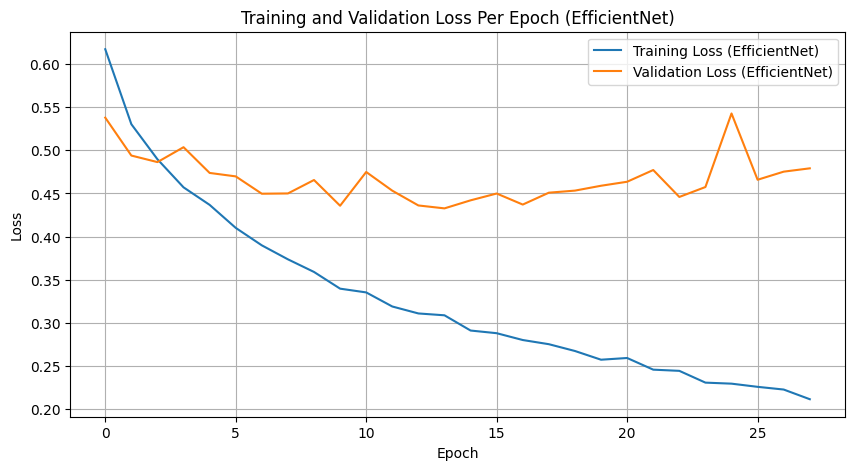

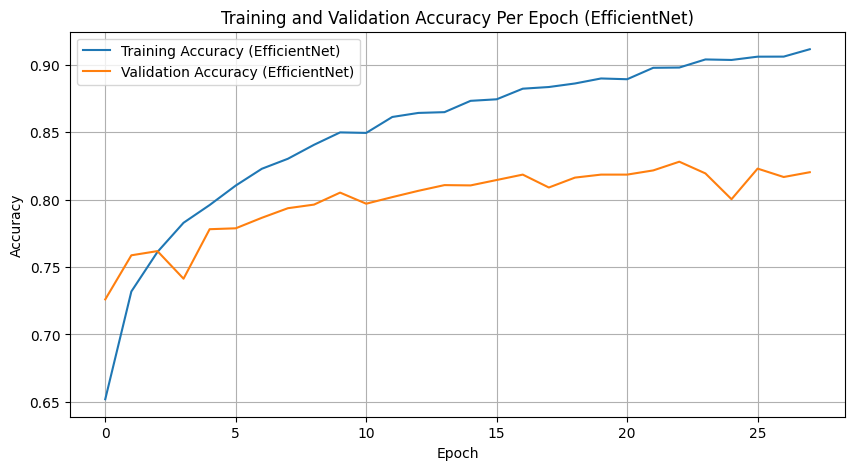

In [15]:
import matplotlib.pyplot as plt

# --- Plotting Training and Validation History for EfficientNet Model ---
print("\n--- Plotting Training and Validation History for EfficientNet Model ---")

# Convert accuracy tensors to CPU numbers for plotting if they are still tensors
# This check ensures compatibility even if a previous cell already converted them.
if isinstance(hist_effnet['train_acc'][0], torch.Tensor):
    hist_effnet['train_acc'] = [acc.cpu().item() for acc in hist_effnet['train_acc']]
if isinstance(hist_effnet['val_acc'][0], torch.Tensor):
    hist_effnet['val_acc'] = [acc.cpu().item() for acc in hist_effnet['val_acc']]

plt.figure(figsize=(10, 5))
plt.plot(hist_effnet['train_loss'], label='Training Loss (EfficientNet)')
plt.plot(hist_effnet['val_loss'], label='Validation Loss (EfficientNet)')
plt.title('Training and Validation Loss Per Epoch (EfficientNet)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(hist_effnet['train_acc'], label='Training Accuracy (EfficientNet)')
plt.plot(hist_effnet['val_acc'], label='Validation Accuracy (EfficientNet)')
plt.title('Training and Validation Accuracy Per Epoch (EfficientNet)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


Evaluating EfficientNet model on test dataset...


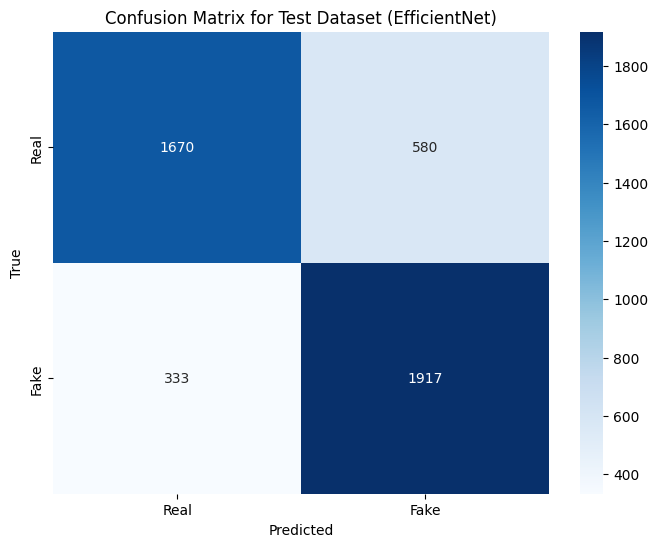


Test Accuracy (EfficientNet): 0.7971
Test Precision (EfficientNet): 0.7677
Test Recall (EfficientNet): 0.8520
Test F1-Score (EfficientNet): 0.8077

Generating ROC curve data for EfficientNet model...


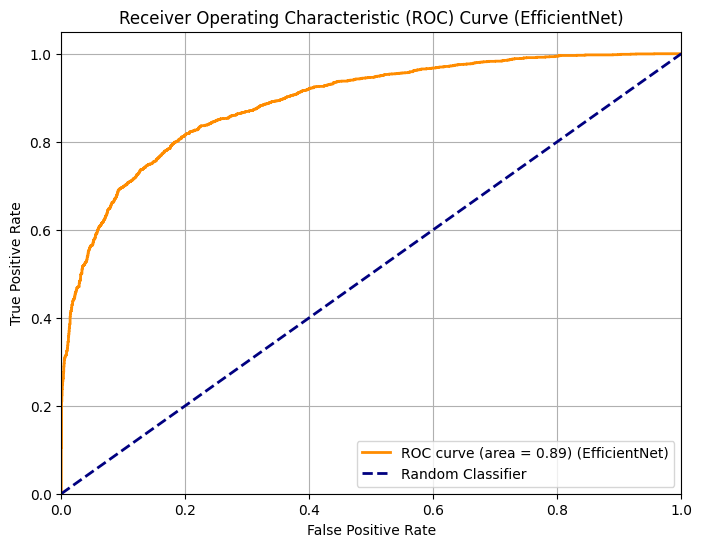

Area Under the Curve (AUC) (EfficientNet): 0.8891


In [16]:
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt
import torch

# Ensure the model is in evaluation mode
model_effnet_ft.eval()

all_labels_effnet = []
all_preds_effnet = []

print("\nEvaluating EfficientNet model on test dataset...")

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model_effnet_ft(inputs)
        _, preds = torch.max(outputs, 1)

        all_labels_effnet.extend(labels.cpu().numpy())
        all_preds_effnet.extend(preds.cpu().numpy())

all_labels_effnet = np.array(all_labels_effnet)
all_preds_effnet = np.array(all_preds_effnet)

# --- Plotting Confusion Matrix for EfficientNet Model ---
cm_effnet = confusion_matrix(all_labels_effnet, all_preds_effnet)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_effnet, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'],
            yticklabels=['Real', 'Fake'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Test Dataset (EfficientNet)')
plt.show()

# Calculate and print other metrics
accuracy_effnet = accuracy_score(all_labels_effnet, all_preds_effnet)
precision_effnet = precision_score(all_labels_effnet, all_preds_effnet, average='binary')
recall_effnet = recall_score(all_labels_effnet, all_preds_effnet, average='binary')
f1_effnet = f1_score(all_labels_effnet, all_preds_effnet, average='binary')

print(f"\nTest Accuracy (EfficientNet): {accuracy_effnet:.4f}")
print(f"Test Precision (EfficientNet): {precision_effnet:.4f}")
print(f"Test Recall (EfficientNet): {recall_effnet:.4f}")
print(f"Test F1-Score (EfficientNet): {f1_effnet:.4f}")

# --- Generating ROC curve for EfficientNet Model ---
print("\nGenerating ROC curve data for EfficientNet model...")

all_labels_roc_effnet = []
all_probs_roc_effnet = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model_effnet_ft(inputs)
        probabilities = torch.softmax(outputs, dim=1)

        all_labels_roc_effnet.extend(labels.cpu().numpy())
        # We need the probability of the positive class (class 1, 'real')
        all_probs_roc_effnet.extend(probabilities[:, 1].cpu().numpy())

fpr_effnet, tpr_effnet, thresholds_effnet = roc_curve(all_labels_roc_effnet, all_probs_roc_effnet)
roc_auc_effnet = auc(fpr_effnet, tpr_effnet)

# Plotting the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_effnet, tpr_effnet, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_effnet:.2f}) (EfficientNet)')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve (EfficientNet)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print(f"Area Under the Curve (AUC) (EfficientNet): {roc_auc_effnet:.4f}")

# Augmented EfficientNet Model - Baseline Model 2

In [17]:
# ============================================================
# CUSTOM AUGMENTATION CLASSES
# Defined here so both Augmented EfficientNet and
# Augmented XceptionNet sections can use them.
# ============================================================

import random
import torch

class SimulateJPEGCompression(object):
    def __init__(self, quality_range=(80, 95), p=0.15):
        self.quality_range = quality_range
        self.p = p

    def __call__(self, tensor):
        if random.random() < self.p:
            quality = random.randint(self.quality_range[0], self.quality_range[1])
            tensor = (torch.round(tensor * quality) / quality)
        return tensor


class AddGaussianNoise(object):
    def __init__(self, mean=0.0, std=0.01, p=0.1):
        self.mean = mean
        self.std = std
        self.p = p

    def __call__(self, tensor):
        if random.random() < self.p:
            noise = torch.randn_like(tensor) * self.std + self.mean
            tensor = tensor + noise
            tensor = torch.clamp(tensor, 0., 1.)
        return tensor

print("Custom augmentation classes defined: SimulateJPEGCompression, AddGaussianNoise")


Custom augmentation classes defined: SimulateJPEGCompression, AddGaussianNoise


In [18]:
# ============================================================
# AUGMENTED EFFICIENTNET - Augmentation Pipeline
# Reuses SimulateJPEGCompression and AddGaussianNoise
# defined in the Augmented XceptionNet section below.
# Run this cell AFTER those classes are defined,
# OR move this section below cell 25.
# ============================================================

# IMG_SIZE for EfficientNet-B0 is 224
IMG_SIZE_EFF = 224

train_transform_aug_eff = transforms.Compose([
    transforms.Resize((IMG_SIZE_EFF, IMG_SIZE_EFF)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.08,
        contrast=0.08,
        saturation=0.05,
        hue=0.02
    ),
    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=3)
    ], p=0.1),
    transforms.ToTensor(),
    AddGaussianNoise(std=0.01, p=0.1),
    SimulateJPEGCompression(quality_range=(80, 95), p=0.15),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform_eff = transforms.Compose([
    transforms.Resize((IMG_SIZE_EFF, IMG_SIZE_EFF)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset_aug_eff = DeepfakeDataset(
    train_fake,
    train_real,
    transform=train_transform_aug_eff
)

train_loader_aug_eff = DataLoader(
    train_dataset_aug_eff,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

# Val and test loaders with EfficientNet-sized images
val_dataset_eff = DeepfakeDataset(
    validation_fake,
    validation_real,
    transform=val_test_transform_eff
)

test_dataset_eff = DeepfakeDataset(
    test_fake,
    test_real,
    transform=val_test_transform_eff
)

val_loader_eff = DataLoader(
    val_dataset_eff,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

test_loader_eff = DataLoader(
    test_dataset_eff,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

print("Augmented EfficientNet data loaders ready.")


Augmented EfficientNet data loaders ready.


In [19]:
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim

# ============================================================
# AUGMENTED EFFICIENTNET-B0 MODEL
# Fresh pretrained weights — not the already fine-tuned model
# ============================================================

model_aug_eff = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.DEFAULT
)

# Freeze all backbone layers first
for param in model_aug_eff.parameters():
    param.requires_grad = False

print("All EfficientNet backbone layers frozen.")

# Unfreeze last 30 parameters (same strategy as baselines)
params_aug_eff = list(model_aug_eff.parameters())
for param in params_aug_eff[max(0, len(params_aug_eff) - 30):]:
    param.requires_grad = True

print("Last 30 parameters unfrozen for fine-tuning.")

# Replace classifier head — same architecture as plain EfficientNet baseline
num_ftrs_aug_eff = model_aug_eff.classifier[1].in_features

model_aug_eff.classifier = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(num_ftrs_aug_eff, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, 128),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(128, 2)
)

print("Custom 3-layer classifier head attached.")

criterion_aug_eff = nn.CrossEntropyLoss()
optimizer_aug_eff = optim.Adam(
    filter(lambda p: p.requires_grad, model_aug_eff.parameters()),
    lr=0.0001
)

model_aug_eff = model_aug_eff.to(device)
print(f"Augmented EfficientNet moved to: {device}")


All EfficientNet backbone layers frozen.
Last 30 parameters unfrozen for fine-tuning.
Custom 3-layer classifier head attached.
Augmented EfficientNet moved to: cuda:0


In [20]:
print("\n--- Starting Augmented EfficientNet-B0 Training ---")

model_aug_eff_ft, hist_aug_eff = train_model(
    model_aug_eff,
    criterion_aug_eff,
    optimizer_aug_eff,
    train_loader_aug_eff,
    val_loader_eff,
    num_epochs=30,
    patience=5,
    save_path="best_efficientnet_aug.pth"
)

print("\nTraining complete for Augmented EfficientNet-B0.")
print("Best model saved to: best_efficientnet_aug.pth")



--- Starting Augmented EfficientNet-B0 Training ---
Epoch 1/30
----------
train Loss: 0.6394 Acc: 0.6263
val Loss: 0.5911 Acc: 0.6762
Best model saved.
Epoch 2/30
----------
train Loss: 0.5760 Acc: 0.6973
val Loss: 0.5602 Acc: 0.7040
Best model saved.
Epoch 3/30
----------
train Loss: 0.5447 Acc: 0.7212
val Loss: 0.5330 Acc: 0.7271
Best model saved.
Epoch 4/30
----------
train Loss: 0.5133 Acc: 0.7441
val Loss: 0.5445 Acc: 0.7269
Epoch 5/30
----------
train Loss: 0.4919 Acc: 0.7604
val Loss: 0.5341 Acc: 0.7291
Best model saved.
Epoch 6/30
----------
train Loss: 0.4698 Acc: 0.7751
val Loss: 0.5255 Acc: 0.7518
Best model saved.
Epoch 7/30
----------
train Loss: 0.4541 Acc: 0.7803
val Loss: 0.5162 Acc: 0.7549
Best model saved.
Epoch 8/30
----------
train Loss: 0.4310 Acc: 0.7952
val Loss: 0.5660 Acc: 0.7431
Epoch 9/30
----------
train Loss: 0.4291 Acc: 0.7979
val Loss: 0.5381 Acc: 0.7509
Epoch 10/30
----------
train Loss: 0.4081 Acc: 0.8082
val Loss: 0.5362 Acc: 0.7482
Epoch 11/30
------

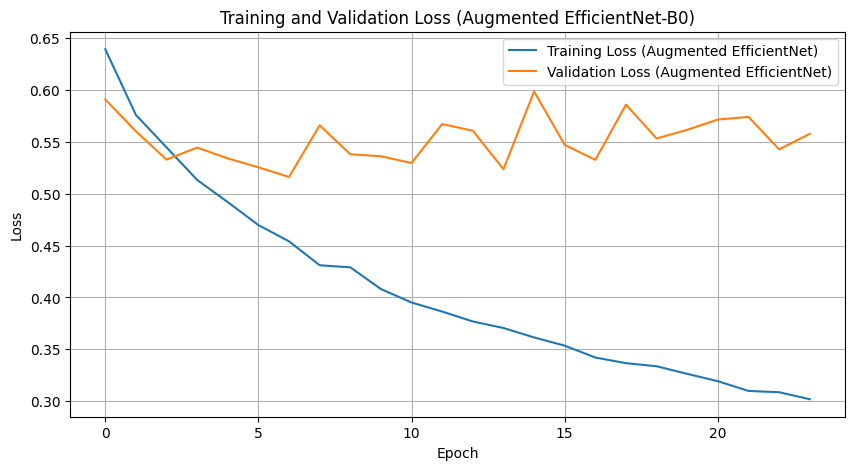

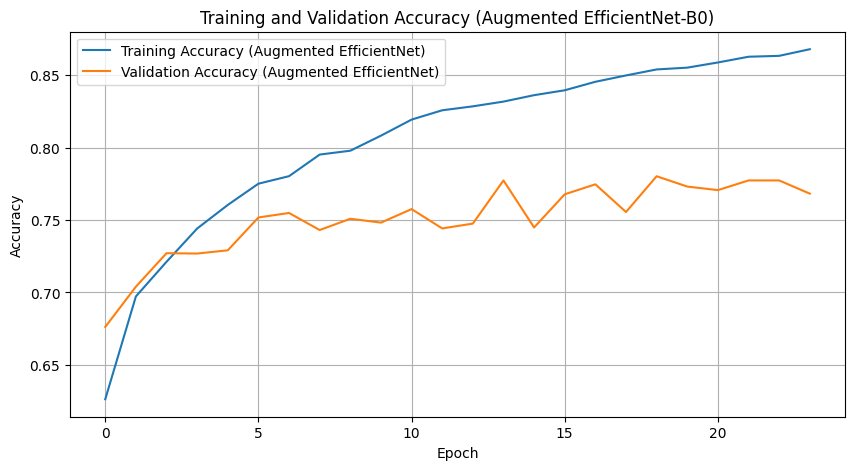


Evaluating Augmented EfficientNet on test dataset...


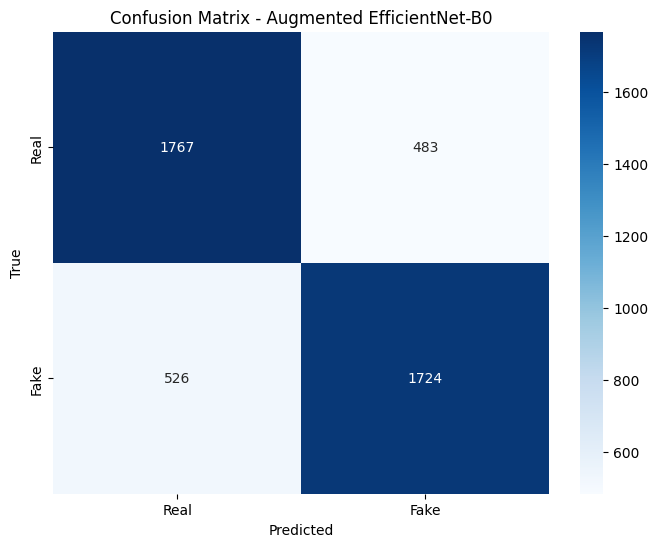


Test Accuracy  (Augmented EfficientNet): 0.7758
Test Precision (Augmented EfficientNet): 0.7812
Test Recall    (Augmented EfficientNet): 0.7662
Test F1-Score  (Augmented EfficientNet): 0.7736


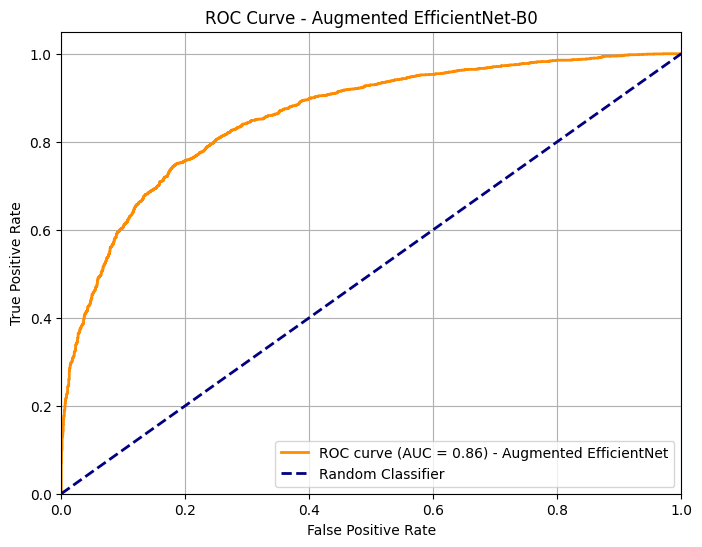

AUC (Augmented EfficientNet): 0.8577


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc

# --- Training curves ---
if isinstance(hist_aug_eff['train_acc'][0], torch.Tensor):
    hist_aug_eff['train_acc'] = [acc.cpu().item() for acc in hist_aug_eff['train_acc']]
if isinstance(hist_aug_eff['val_acc'][0], torch.Tensor):
    hist_aug_eff['val_acc'] = [acc.cpu().item() for acc in hist_aug_eff['val_acc']]

plt.figure(figsize=(10, 5))
plt.plot(hist_aug_eff['train_loss'], label='Training Loss (Augmented EfficientNet)')
plt.plot(hist_aug_eff['val_loss'], label='Validation Loss (Augmented EfficientNet)')
plt.title('Training and Validation Loss (Augmented EfficientNet-B0)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(hist_aug_eff['train_acc'], label='Training Accuracy (Augmented EfficientNet)')
plt.plot(hist_aug_eff['val_acc'], label='Validation Accuracy (Augmented EfficientNet)')
plt.title('Training and Validation Accuracy (Augmented EfficientNet-B0)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# --- Test evaluation ---
model_aug_eff_ft.eval()

all_labels_aug_eff = []
all_preds_aug_eff = []

print("\nEvaluating Augmented EfficientNet on test dataset...")

with torch.no_grad():
    for inputs, labels in test_loader_eff:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model_aug_eff_ft(inputs)
        _, preds = torch.max(outputs, 1)
        all_labels_aug_eff.extend(labels.cpu().numpy())
        all_preds_aug_eff.extend(preds.cpu().numpy())

all_labels_aug_eff = np.array(all_labels_aug_eff)
all_preds_aug_eff = np.array(all_preds_aug_eff)

# Confusion matrix
cm_aug_eff = confusion_matrix(all_labels_aug_eff, all_preds_aug_eff)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_aug_eff, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'],
            yticklabels=['Real', 'Fake'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Augmented EfficientNet-B0')
plt.show()

# Metrics
accuracy_aug_eff   = accuracy_score(all_labels_aug_eff, all_preds_aug_eff)
precision_aug_eff  = precision_score(all_labels_aug_eff, all_preds_aug_eff, average='binary')
recall_aug_eff     = recall_score(all_labels_aug_eff, all_preds_aug_eff, average='binary')
f1_aug_eff         = f1_score(all_labels_aug_eff, all_preds_aug_eff, average='binary')

print(f"\nTest Accuracy  (Augmented EfficientNet): {accuracy_aug_eff:.4f}")
print(f"Test Precision (Augmented EfficientNet): {precision_aug_eff:.4f}")
print(f"Test Recall    (Augmented EfficientNet): {recall_aug_eff:.4f}")
print(f"Test F1-Score  (Augmented EfficientNet): {f1_aug_eff:.4f}")

# ROC curve
all_labels_roc_aug_eff = []
all_probs_roc_aug_eff  = []

with torch.no_grad():
    for inputs, labels in test_loader_eff:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model_aug_eff_ft(inputs)
        probabilities = torch.softmax(outputs, dim=1)
        all_labels_roc_aug_eff.extend(labels.cpu().numpy())
        all_probs_roc_aug_eff.extend(probabilities[:, 1].cpu().numpy())

fpr_aug_eff, tpr_aug_eff, _ = roc_curve(all_labels_roc_aug_eff, all_probs_roc_aug_eff)
roc_auc_aug_eff = auc(fpr_aug_eff, tpr_aug_eff)

plt.figure(figsize=(8, 6))
plt.plot(fpr_aug_eff, tpr_aug_eff, color='darkorange', lw=2,
         label=f'ROC curve (AUC = {roc_auc_aug_eff:.2f}) - Augmented EfficientNet')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Augmented EfficientNet-B0')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print(f"AUC (Augmented EfficientNet): {roc_auc_aug_eff:.4f}")


# Final Results

In [23]:
import json
import numpy as np

class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        if isinstance(obj, np.floating):
            return float(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return super().default(obj)

data_to_save = {}

# --- baseline efficientnet ---
data_to_save["hist_effnet"] = {
    "train_loss" : hist_effnet["train_loss"],
    "val_loss"   : hist_effnet["val_loss"],
    "train_acc"  : [float(v) for v in hist_effnet["train_acc"]],
    "val_acc"    : [float(v) for v in hist_effnet["val_acc"]],
}

# --- augmented efficientnet ---
data_to_save["hist_aug_eff"] = {
    "train_loss" : hist_aug_eff["train_loss"],
    "val_loss"   : hist_aug_eff["val_loss"],
    "train_acc"  : [float(v) for v in hist_aug_eff["train_acc"]],
    "val_acc"    : [float(v) for v in hist_aug_eff["val_acc"]],
}

# test set predictions + roc stuff for both models
data_to_save["effnet_eval"] = {
    "labels"     : all_labels_effnet.tolist(),
    "preds"      : all_preds_effnet.tolist(),
    "fpr"        : fpr_effnet.tolist(),
    "tpr"        : tpr_effnet.tolist(),
    "auc"        : float(roc_auc_effnet),
    "probs"      : all_probs_roc_effnet,
}

data_to_save["aug_eff_eval"] = {
    "labels"     : all_labels_aug_eff.tolist(),
    "preds"      : all_preds_aug_eff.tolist(),
    "fpr"        : fpr_aug_eff.tolist(),
    "tpr"        : tpr_aug_eff.tolist(),
    "auc"        : float(roc_auc_aug_eff),
    "probs"      : all_probs_roc_aug_eff,
}

print(json.dumps(data_to_save, indent=2, cls=NumpyEncoder))

{
  "hist_effnet": {
    "train_loss": [
      0.6170752917698451,
      0.5302227932612101,
      0.4895901160240173,
      0.4570571620804923,
      0.4367479696500869,
      0.41009772300720215,
      0.38986039284297397,
      0.3736676997003101,
      0.3590278712908427,
      0.3396763664881388,
      0.33532754269100373,
      0.31901506421679543,
      0.3109584173616909,
      0.3088159434114184,
      0.29116529614584785,
      0.28808145258540196,
      0.28017134962763107,
      0.2753364582515898,
      0.26745790679114206,
      0.25736518489179155,
      0.2593453322478703,
      0.2458408295086452,
      0.24445961588904971,
      0.23081334295159295,
      0.2296190674304962,
      0.22593925485156832,
      0.22280531599975767,
      0.21158949537504287
    ],
    "val_loss": [
      0.5378062359491984,
      0.49389174903763666,
      0.48630453324317935,
      0.503561590883467,
      0.47375074209107293,
      0.46974802663591175,
      0.4496632600360447,
      0.